
# Part 21 — Linear Regression Foundations

Independent study notes for the first supervised-learning concepts in Month 1.

This notebook is intentionally **rewritten from scratch**. It contains my own summaries, equations, and small toy experiments; it does not include course-provided solution cells, figures, datasets, or helper utilities.

## What I want to retain

- What supervised learning is and where regression fits
- The roles of features, targets, parameters, and predictions
- The linear model $f_{w,b}(x)=wx+b$
- What the cost function $J(w,b)$ measures
- Why minimizing cost is the learning objective
- How gradient descent updates $w$ and $b$
- What the learning rate $\alpha$ controls
- How to recognize convergence and divergence



## 1. Supervised learning

In supervised learning, each training example contains an input and a known target:

$$
(x^{(i)}, y^{(i)})
$$

The model learns a mapping from $x$ to $y$ by using these labeled examples.

Two common supervised-learning settings are:

- **Regression:** predict a continuous value.
- **Classification:** predict a category or class.

This notebook focuses on **regression**.

### Core notation

| Symbol | Meaning |
|---|---|
| $x^{(i)}$ | feature/input of training example $i$ |
| $y^{(i)}$ | target of training example $i$ |
| $m$ | number of training examples |
| $w,b$ | model parameters |
| $\hat y^{(i)}$ | model prediction |
| $J(w,b)$ | cost over the training set |



## 2. Model representation

For one-variable linear regression, the prediction function is

$$
f_{w,b}(x)=wx+b.
$$

For the $i$-th training example:

$$
\hat y^{(i)} = f_{w,b}(x^{(i)}) = wx^{(i)}+b.
$$

The important distinction is:

- $x$ is **data**.
- $w$ and $b$ are **parameters learned from data**.
- $\hat y$ is the **prediction produced by the current parameters**.

Changing $w$ changes the slope of the line.  
Changing $b$ shifts the line vertically.


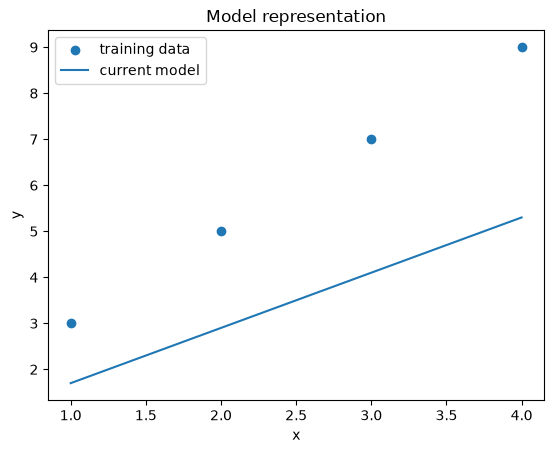

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A tiny dataset created only for these notes.
# It follows y = 2x + 1 exactly.
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([3.0, 5.0, 7.0, 9.0])

def predict(x, w, b):
    return w * x + b

w = 1.2
b = 0.5

y_hat = predict(x, w, b)

plt.scatter(x, y, label="training data")
plt.plot(x, y_hat, label="current model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Model representation")
plt.legend()
plt.show()



The previous model is only one possible line. Learning means finding parameter values that make the predictions fit the observed targets well.

That requires a quantitative definition of **"fit well."**



## 3. Squared-error cost

For one example, the residual is

$$
e^{(i)} = \hat y^{(i)} - y^{(i)}.
$$

Squaring the residual gives

$$
(e^{(i)})^2
=
\left(f_{w,b}(x^{(i)})-y^{(i)}\right)^2.
$$

A common cost function for linear regression is

$$
J(w,b)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(
f_{w,b}(x^{(i)})-y^{(i)}
\right)^2.
$$

Interpretation:

- Perfect predictions produce zero residuals.
- Larger prediction errors contribute more to the cost.
- $J(w,b)$ summarizes the errors of the **whole training set** into one scalar.
- Training searches for parameters that minimize this scalar.

The factor $\frac{1}{2m}$ rescales the objective but does not change which $w,b$ minimize it.

The deeper probabilistic reason that Gaussian residual assumptions lead to squared error is handled separately in **Part 22 — MLE to Squared Loss**.


In [2]:
def cost(x, y, w, b):
    m = len(x)
    residuals = predict(x, w, b) - y
    return np.sum(residuals ** 2) / (2 * m)

print("Current cost:", cost(x, y, w, b))
print("Cost at w=2, b=1:", cost(x, y, 2.0, 1.0))


Current cost: 3.5250000000000004
Cost at w=2, b=1: 0.0



## 4. Cost as a function of the parameters

The model parameters determine the predictions, so they also determine the cost:

$$
(w,b)
\longrightarrow
\hat y
\longrightarrow
\text{residuals}
\longrightarrow
J(w,b).
$$

For one-variable linear regression with squared error, the cost surface is convex.  
That is important because there is a single global basin rather than multiple competing local minima.

To see one slice of the surface, keep $b$ fixed and vary $w$.


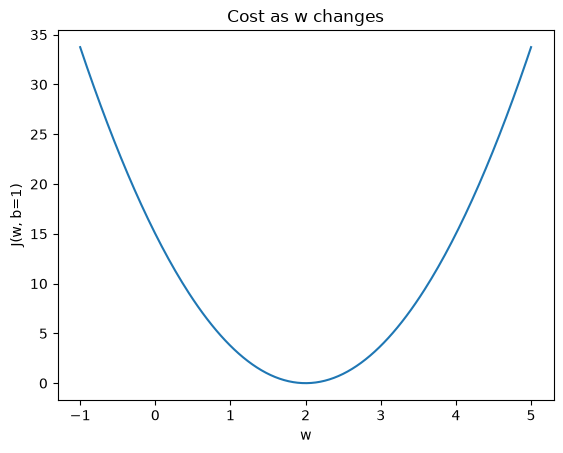

In [3]:
w_values = np.linspace(-1, 5, 200)
b_fixed = 1.0

cost_values = [cost(x, y, w_value, b_fixed) for w_value in w_values]

plt.plot(w_values, cost_values)
plt.xlabel("w")
plt.ylabel("J(w, b=1)")
plt.title("Cost as w changes")
plt.show()



The minimum occurs near the parameter value that best fits the data.

So the modeling problem can be written as an optimization problem:

$$
(w^*,b^*)
=
\arg\min_{w,b} J(w,b).
$$

The next question is not *what* we want, but **how to find it efficiently**.



## 5. Gradient descent

Gradient descent repeatedly moves the parameters in the direction that reduces the cost.

The update rule is

$$
w \leftarrow
w-\alpha\frac{\partial J(w,b)}{\partial w}
$$

and

$$
b \leftarrow
b-\alpha\frac{\partial J(w,b)}{\partial b}.
$$

For squared-error linear regression,

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
f_{w,b}(x^{(i)})-y^{(i)}
\right)x^{(i)}
$$

and

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
f_{w,b}(x^{(i)})-y^{(i)}
\right).
$$

### Meaning of the gradient

The derivative tells us how the cost changes locally when a parameter changes.

- Positive derivative $\rightarrow$ increasing the parameter increases cost locally.
- Negative derivative $\rightarrow$ increasing the parameter decreases cost locally.
- Near a minimum, the derivatives approach zero.

The minus sign in gradient descent makes the update move **against** the local uphill direction.



### Simultaneous update

Conceptually, the new values of $w$ and $b$ should be computed from the **same old parameter state**:

$$
w_{\text{new}}
=
w_{\text{old}}
-\alpha
\frac{\partial J(w_{\text{old}},b_{\text{old}})}{\partial w}
$$

$$
b_{\text{new}}
=
b_{\text{old}}
-\alpha
\frac{\partial J(w_{\text{old}},b_{\text{old}})}{\partial b}.
$$

This keeps one gradient-descent step mathematically consistent.


In [4]:
def gradients(x, y, w, b):
    m = len(x)
    residuals = predict(x, w, b) - y

    dj_dw = np.sum(residuals * x) / m
    dj_db = np.sum(residuals) / m

    return dj_dw, dj_db

dw, db = gradients(x, y, w=0.0, b=0.0)
print("dJ/dw:", dw)
print("dJ/db:", db)


dJ/dw: -17.5
dJ/db: -6.0



## 6. Learning rate

The learning rate $\alpha$ controls the step size.

$$
\text{parameter change}
=
-\alpha \times \text{gradient}.
$$

### If $\alpha$ is too small

- Optimization can move in the correct direction but very slowly.
- Many iterations may be required.

### If $\alpha$ is reasonable

- Cost decreases steadily.
- Parameters approach the minimum.

### If $\alpha$ is too large

- Updates can overshoot the minimum.
- Parameters may oscillate.
- Cost can increase instead of decrease.
- The algorithm can diverge.

This is the first important connection between calculus and an actual ML algorithm: the derivative gives the direction, while the learning rate turns that information into a controlled numerical update.


In [5]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iters):
    w = float(w_init)
    b = float(b_init)
    history = []

    for _ in range(num_iters):
        dj_dw, dj_db = gradients(x, y, w, b)

        new_w = w - alpha * dj_dw
        new_b = b - alpha * dj_db

        w, b = new_w, new_b
        history.append(cost(x, y, w, b))

    return w, b, np.array(history)

w_fit, b_fit, history = gradient_descent(
    x, y,
    w_init=0.0,
    b_init=0.0,
    alpha=0.05,
    num_iters=200
)

print(f"Learned w: {w_fit:.4f}")
print(f"Learned b: {b_fit:.4f}")
print(f"Final cost: {history[-1]:.8f}")


Learned w: 2.0217
Learned b: 0.9362
Final cost: 0.00033974


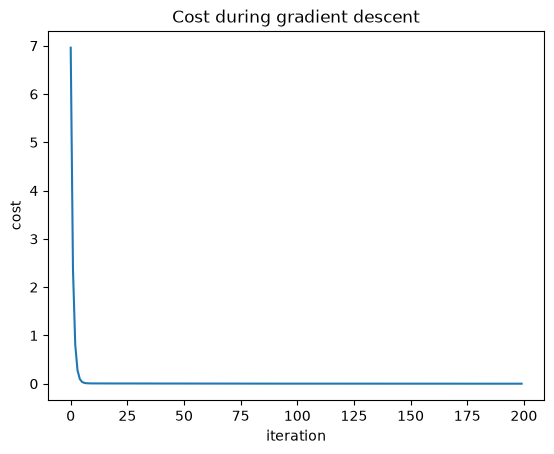

In [6]:
plt.plot(np.arange(len(history)), history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("Cost during gradient descent")
plt.show()



## 7. Convergence intuition

Useful signals while training:

### Healthy run

$$
J_0 > J_1 > J_2 > \cdots
$$

The cost generally trends downward and the parameter updates become smaller as the gradient approaches zero.

### Suspicious run

If the cost repeatedly rises or explodes, the learning rate is a first thing to inspect.

For this simple convex problem, gradient descent with an appropriate learning rate should approach the global minimum.



## 8. Concept map

The full Week 1 chain can be summarized as:

$$
\text{training data }(X,y)
\rightarrow
\text{model }f_{w,b}
\rightarrow
\text{predictions}
\rightarrow
\text{cost }J(w,b)
\rightarrow
\text{gradients}
\rightarrow
\text{parameter updates}
\rightarrow
\text{lower cost}.
$$

Or in words:

1. Define what the model predicts.
2. Measure how wrong those predictions are.
3. Treat learning as an optimization problem.
4. Use derivatives to determine a locally improving direction.
5. Use the learning rate to decide how large each update should be.
6. Repeat until the optimization has converged sufficiently.


## 9. Connection to the flagship

My flagship is a **regression** problem.

For the project, the corresponding pieces are:

- **$X$:** the model-ready feature columns.
- **$y$:** the continuous regression target.
- **Model:** a function parameterized by values learned from the training data.
- **Objective/loss:** chosen according to the modeling assumptions and practical goal.
- **Split:** training and evaluation data must remain separated to avoid leakage.
- **Metric:** used to evaluate generalization; it is conceptually distinct from the training objective.

The probabilistic justification for starting with squared error is documented in:

`notebooks/month1/part22_mle_to_squared_loss.md`


## 10. Recall checkpoint

Without looking above, I should be able to answer:

1. What is the difference between $x$, $y$, $\hat y$, $w$, and $b$?
2. What does $J(w,b)$ measure?
3. Why does changing $w$ or $b$ change the cost?
4. What does $\frac{\partial J}{\partial w}$ tell me?
5. Why is there a minus sign in the gradient-descent update?
6. What is the job of the learning rate?
7. What behavior suggests the learning rate is too large?
8. Why is convexity useful for this linear-regression objective?
9. What is the distinction between the objective used for training and the metric used for evaluation?
10. What probabilistic question is deferred to Part 22?
